# End-to-End ML Project: Iris Classification
**Goal:** Train multiple models, evaluate, visualize errors & features, plot learning curves in order to solidify my understanding of machine learning concepts

In [14]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
%matplotlib inline
sns.set(style="whitegrid")

In [15]:
# Load dataset
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


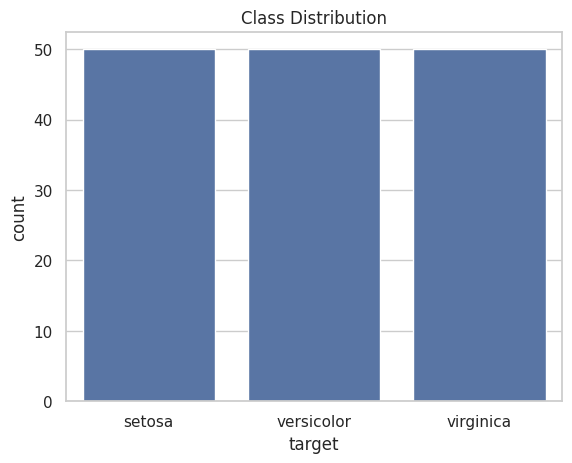

In [3]:
# EDA - Class distribution
sns.countplot(x='target', data=df)
plt.xticks(ticks=[0,1,2], labels=target_names)
plt.title("Class Distribution")
plt.show()

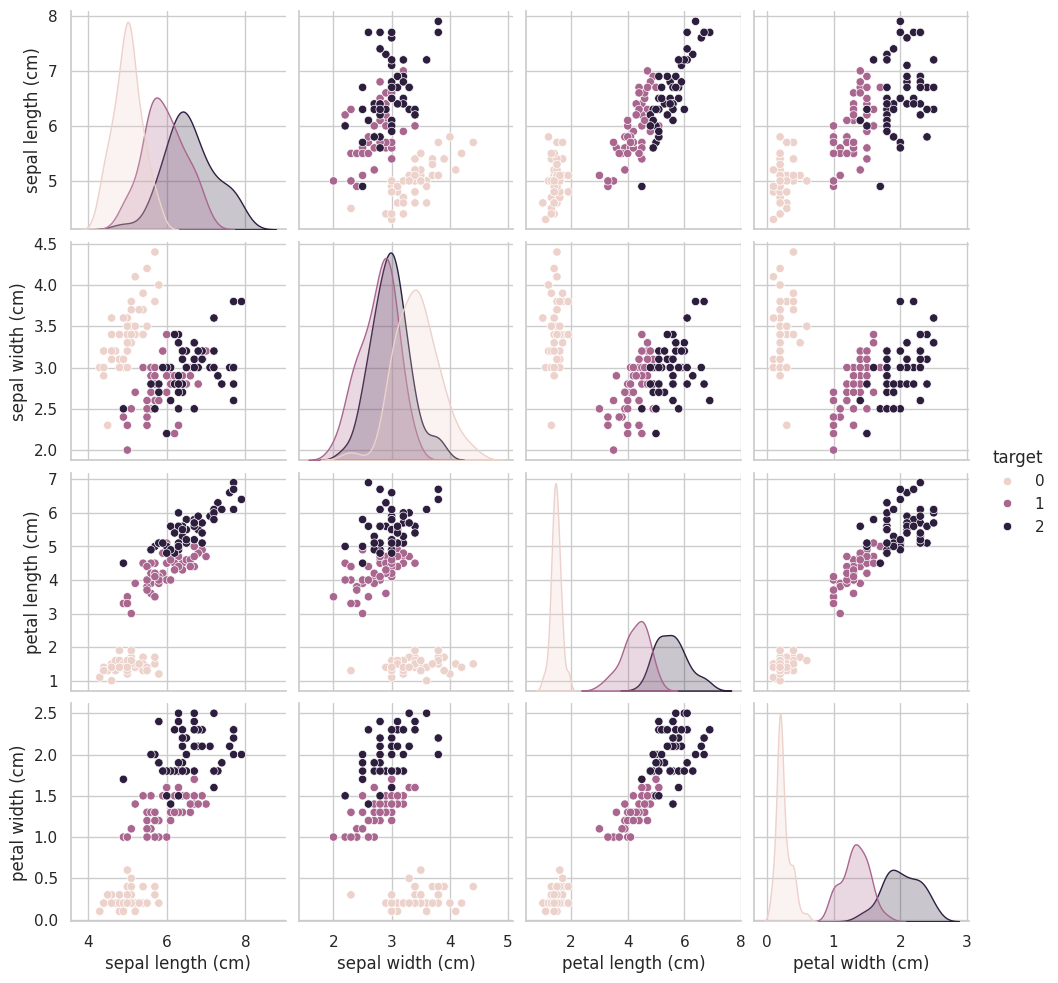

In [4]:
# Pairplot
sns.pairplot(df, hue='target', vars=feature_names)
plt.show()

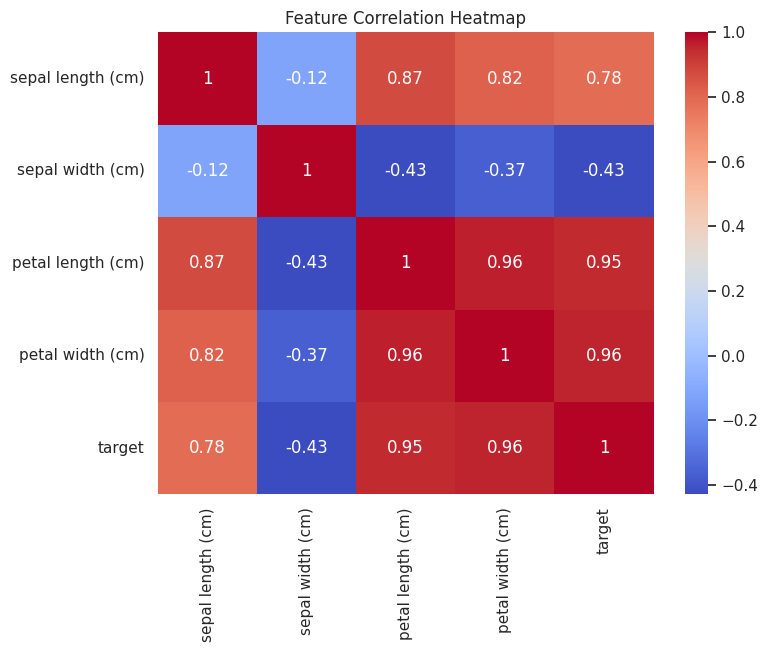

In [5]:
# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
# Preprocessing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression Accuracy: 0.933
Random Forest Accuracy: 0.933
SVM Accuracy: 0.967


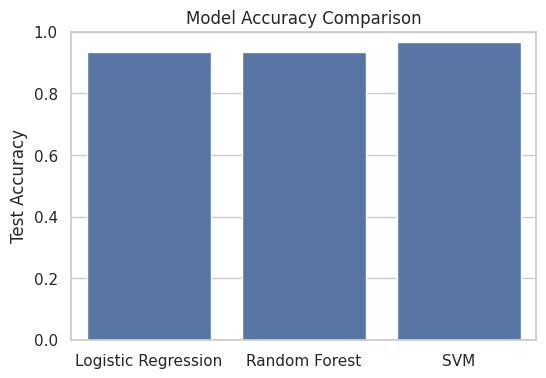

In [8]:
# Model training & comparison
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(probability=True)
}
model_results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    model_results[name] = acc
    print(f"{name} Accuracy: {acc:.3f}")
plt.figure(figsize=(6,4))
sns.barplot(x=list(model_results.keys()), y=list(model_results.values()))
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

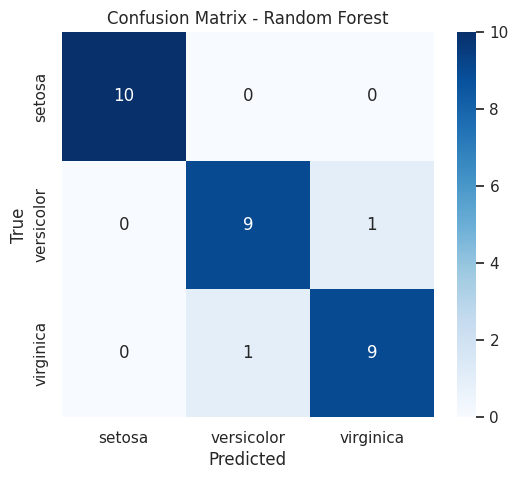

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [9]:
# Confusion matrix for Random Forest
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Random Forest")
plt.show()
print(classification_report(y_test, y_pred_best, target_names=target_names))

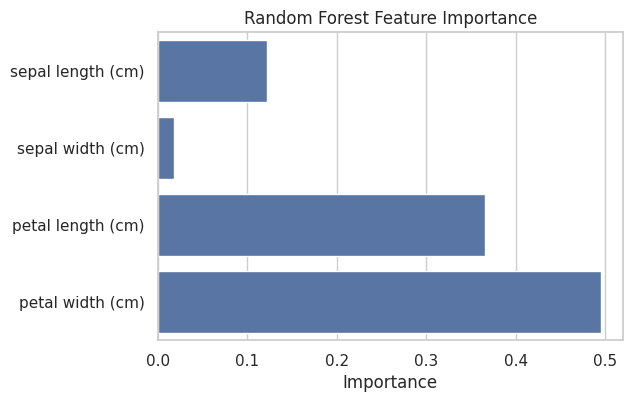

In [10]:
# Feature importance
importances = best_model.feature_importances_
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=feature_names)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

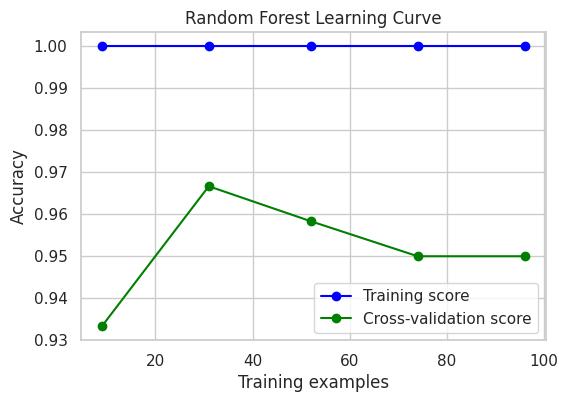

In [11]:
# Learning curve function
def plot_learning_curve(model, X, y, title="Learning Curve"):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, train_sizes=np.linspace(0.1,1.0,5), scoring='accuracy', n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    plt.figure(figsize=(6,4))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="green", label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()
# Example: Random Forest
plot_learning_curve(best_model, X_train_scaled, y_train, title="Random Forest Learning Curve")

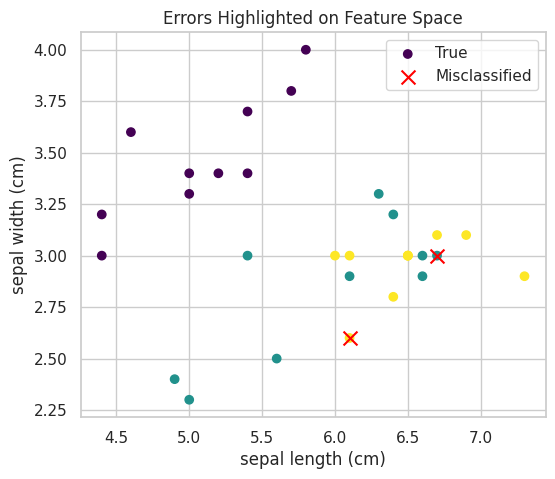

In [12]:
# Highlight misclassified points on first 2 features
errors = y_test != y_pred_best
plt.figure(figsize=(6,5))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='viridis', label='True')
plt.scatter(X_test[errors,0], X_test[errors,1], c='red', marker='x', s=100, label='Misclassified')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Errors Highlighted on Feature Space")
plt.legend()
plt.show()

## Conclusions & Next Steps
- Random Forest achieved highest accuracy.
- Most errors occur between classes 1 and 2.
- Petal length and width are the most informative features.
- Learning curves indicate minimal overfitting.
- Next: cross-validation, neural networks, hyperparameter tuning, new datasets.